# Nifty 50 Options — Three-Sleeve Intraday Strategy

**Sleeves:** Mean Reversion | Trend Following | Semi-Directional  
**Ensemble:** Static 0.45 MR / 0.00 TR / 0.55 SD (reporting) · Returns-weighted dynamic (live)  
**Data:** `nifty_options_chain_clean` parquet, minute bars  
**Test window:** 2025-01-01 → 2026-05-15 (warm-up from 2023 for feature initialisation)


## 1 · Imports & Config


In [6]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

TRADING_DAYS_PER_YEAR = 252
INITIAL_EQUITY        = 100.0
RISK_FREE_RATE        = 0.07   # INR overnight proxy
PARQUET_PATH          = r'C:\Users\Admin\Downloads\nifty_options_chain_clean_2023-01-02_to_2026-05-15.parquet'
TEST_START            = pd.Timestamp('2025-01-01')


## 2 · Load & Filter Data


In [7]:
raw = pd.read_parquet(PARQUET_PATH, engine='fastparquet')
raw = raw[
    (raw['expiry']     >= '2023-01-01') &
    (raw['bar_minute'] >= '2023-01-01')
].copy()
raw['bar_minute'] = pd.to_datetime(raw['bar_minute'])
raw['expiry']     = pd.to_datetime(raw['expiry'])
print(f"{len(raw):,} rows  |  {raw['bar_minute'].dt.date.nunique()} trading days  "
      f"|  {raw['bar_minute'].min().date()} → {raw['bar_minute'].max().date()}")
raw.head(3)


91,252,866 rows  |  702 trading days  |  2023-01-02 → 2026-05-15


,ticker,bar_minute,open,high,low,close,volume,expiry,opt_type,strike,feed_era,is_closing_bar
0,NIFTY230105P15050,2023-01-02 09:15:00,0.6,0.60,0.50,0.50,3750,2023-01-05,P,15050.0,vendor59,False
1,NIFTY230105P15100,2023-01-02 09:15:00,0.5,0.55,0.40,0.40,3050,2023-01-05,P,15100.0,vendor59,False
2,NIFTY230105P15150,2023-01-02 09:15:00,0.6,0.60,0.55,0.55,1750,2023-01-05,P,15150.0,vendor59,False


## 3 · Synthetic Spot (Put-Call Parity on Front-Month ATM)


In [8]:
front_expiry = raw.groupby('bar_minute')['expiry'].min().reset_index()
front_data   = raw.merge(front_expiry, on=['bar_minute', 'expiry'], how='inner')

front_pivot = (
    front_data
    .pivot_table(index=['bar_minute', 'strike'], columns='opt_type',
                 values='close', aggfunc='first')
    .dropna().reset_index()
)
front_pivot['synthetic_spot'] = front_pivot['strike'] + (front_pivot['C'] - front_pivot['P'])
front_pivot['atm_dist']       = (front_pivot['strike'] - front_pivot['synthetic_spot']).abs()

atm_df = (
    front_pivot
    .loc[front_pivot.groupby('bar_minute')['atm_dist'].idxmin()]
    .rename(columns={'C': 'call_price', 'P': 'put_price'})
    .sort_values('bar_minute').reset_index(drop=True)
)
atm_df['spot'] = atm_df['synthetic_spot']

# OTM legs for semi-directional
strike_steps = np.diff(np.sort(atm_df['strike'].unique()))
strike_step  = int(np.nanmin(strike_steps)) if len(strike_steps) else 100
atm_df['strike_otm_call'] = atm_df['strike'] + strike_step
atm_df['strike_otm_put']  = atm_df['strike'] - strike_step

otm_call = front_pivot[['bar_minute','strike','C']].rename(columns={'strike':'strike_otm','C':'otm_call_price'})
otm_put  = front_pivot[['bar_minute','strike','P']].rename(columns={'strike':'strike_otm','P':'otm_put_price'})

atm_df = (
    atm_df
    .merge(otm_call, left_on=['bar_minute','strike_otm_call'], right_on=['bar_minute','strike_otm'], how='left').drop(columns=['strike_otm'])
    .merge(otm_put,  left_on=['bar_minute','strike_otm_put'],  right_on=['bar_minute','strike_otm'], how='left').drop(columns=['strike_otm'])
    .sort_values('bar_minute').reset_index(drop=True)
)
print(f'ATM rows: {len(atm_df):,}')
atm_df.head(3)


ATM rows: 263,625


opt_type,bar_minute,strike,call_price,put_price,synthetic_spot,atm_dist,spot,strike_otm_call,strike_otm_put,otm_call_price,otm_put_price
0,2023-01-02 09:15:00,18150.0,102.95,107.55,18145.40,4.60,18145.40,18200.0,18100.0,80.40,85.20
1,2023-01-02 09:16:00,18150.0,100.45,110.85,18139.60,10.40,18139.60,18200.0,18100.0,77.45,87.70
2,2023-01-02 09:17:00,18150.0,101.55,108.00,18143.55,6.45,18143.55,18200.0,18100.0,78.50,85.15


## 4 · Intraday Features (ATR, AEMA)


In [9]:
sd = atm_df.copy()
sd['date'] = sd['bar_minute'].dt.date
sd = sd.sort_values(['date','bar_minute']).reset_index(drop=True)

# True Range ATR (14-bar)
sd['tr']       = sd['spot'].diff().abs()
sd['atr']      = sd['tr'].rolling(14, min_periods=5).mean()
sd['atr_norm'] = sd['atr'] / sd['spot']

# Adaptive EMA alpha from expanding ATR normalisation (no lookahead)
atr_min = sd['atr_norm'].expanding().min()
atr_max = sd['atr_norm'].expanding().max()
sd['aema_alpha'] = (sd['atr_norm'] - atr_min) / (atr_max - atr_min + 1e-8)

# AEMA (state-dependent — must loop)
aema = np.empty(len(sd)); aema[0] = sd['spot'].iloc[0]
for i in range(1, len(sd)):
    s = sd['spot'].iloc[i]; a = sd['aema_alpha'].iloc[i]
    aema[i] = a*s + (1-a)*aema[i-1] if not (np.isnan(s) or np.isnan(a)) else aema[i-1]
sd['aema'] = aema

sd['trend']          = sd['spot'] - sd['aema']
sd['trend_strength'] = sd['trend'].abs() / sd['atr'].replace(0, np.nan)
print('Features computed.')


Features computed.


## 5 · Daily Aggregation


In [10]:
daily = (
    sd.groupby('date')
    .agg(spot_open=('spot','first'), spot_high=('spot','max'),
         spot_low=('spot','min'),   spot_close=('spot','last'),
         aema_close=('aema','last'), atr_close=('atr','last'))
    .reset_index().sort_values('date').reset_index(drop=True)
)
daily = daily[daily['spot_open'] > 0].copy()

# Lag-1 features (signals only see prior-day info)
daily['prev_close'] = daily['spot_close'].shift(1)
daily['prev_high']  = daily['spot_high'].shift(1)
daily['prev_low']   = daily['spot_low'].shift(1)

# Gap-contamination guard
daily['days_gap'] = pd.to_datetime(daily['date']).diff().dt.days
daily['gap_flag'] = daily['days_gap'] > 10
daily['near_gap'] = daily['gap_flag'].rolling(20, min_periods=1).max().astype(bool)
print(f"Gap-contaminated rows: {daily['near_gap'].sum()}")

# Daily OHLC ATR
daily['tr_daily']  = np.maximum.reduce([
    daily['spot_high'] - daily['spot_low'],
    (daily['spot_high'] - daily['prev_close']).abs(),
    (daily['spot_low']  - daily['prev_close']).abs(),
])
daily['atr_daily'] = daily['tr_daily'].rolling(14, min_periods=5).mean()

# EWM trend features
daily['trend_fast'] = daily['prev_close'].ewm(span=5,  adjust=False).mean()
daily['trend_slow'] = daily['prev_close'].ewm(span=20, adjust=False).mean()
daily['trend_gap']  = daily['trend_fast'] - daily['trend_slow']
daily['trend_mom']  = daily['trend_gap'] / daily['trend_slow'].replace(0, np.nan)
daily['breakout_str'] = (daily['spot_open'] - daily['prev_close']).abs() / daily['atr_daily'].replace(0, np.nan)
daily['trend_str']    = daily['trend_gap'].abs() / daily['atr_daily'].replace(0, np.nan)

# Z-score for mean-reversion
daily['mr_mean']   = daily['prev_close'].rolling(20, min_periods=10).mean()
daily['mr_std']    = daily['prev_close'].rolling(20, min_periods=10).std().replace(0, np.nan)
daily['mr_zscore'] = (daily['spot_open'] - daily['mr_mean']) / daily['mr_std']

daily[['date','spot_open','spot_close','mr_zscore','atr_daily']].tail(5)


Gap-contaminated rows: 38


,date,spot_open,spot_close,mr_zscore,atr_daily
697,2026-04-29,24100.35,24168.15,0.628650,405.503571
698,2026-04-30,23977.00,24078.75,0.398466,395.782143
699,2026-05-13,23475.50,23469.40,-0.353299,413.857143
700,2026-05-14,23540.50,23735.05,-0.291829,327.375000
701,2026-05-15,23707.05,23657.05,-0.093643,313.921429


## 6 · Signals

| Sleeve | Trigger | Direction |
|--------|---------|----------|
| **Mean Reversion** | Z-score < −1 or > +1 on open | Fade the move |
| **Trend Following** | EWM crossover + momentum + breakout strength | Follow the move |
| **Semi-Directional** | Open gaps above prev-high / below prev-low by ≥ 0.2 ATR | Follow gap direction |


In [11]:
# ── Mean reversion ──
daily['mean_signal'] = 0
daily.loc[daily['mr_zscore'] < -1.0, 'mean_signal'] =  1
daily.loc[daily['mr_zscore'] >  1.0, 'mean_signal'] = -1

# ── Trend following ──
MOM_THR, STR_THR, BRK_THR = 0.0015, 0.35, 0.20
daily['trend_signal'] = 0
daily.loc[
    (daily['spot_open'] > daily['prev_close']) & (daily['trend_gap'] > 0) &
    (daily['trend_mom'] > MOM_THR) & (daily['trend_str'] > STR_THR) &
    (daily['breakout_str'] > BRK_THR), 'trend_signal'] = 1
daily.loc[
    (daily['spot_open'] < daily['prev_close']) & (daily['trend_gap'] < 0) &
    (daily['trend_mom'] < -MOM_THR) & (daily['trend_str'] > STR_THR) &
    (daily['breakout_str'] > BRK_THR), 'trend_signal'] = -1

# ── Semi-directional ──
SEMI_MIN_ATR = 0.20
long_brk  = daily['spot_open'] > daily['prev_high']
short_brk = daily['spot_open'] < daily['prev_low']
semi_str  = pd.Series(np.nan, index=daily.index)
semi_str[long_brk]  = (daily['spot_open'] - daily['prev_high']) / daily['atr_daily'].replace(0, np.nan)
semi_str[short_brk] = (daily['prev_low']  - daily['spot_open']) / daily['atr_daily'].replace(0, np.nan)
daily['semi_signal'] = 0
daily.loc[long_brk  & (semi_str >= SEMI_MIN_ATR), 'semi_signal'] =  1
daily.loc[short_brk & (semi_str >= SEMI_MIN_ATR), 'semi_signal'] = -1

# Suppress gap-contaminated rows for MR and Trend
daily.loc[daily['near_gap'], ['mean_signal', 'trend_signal']] = 0

# Daily P&L (open → close)
for lbl, sig in [('mean','mean_signal'),('trend','trend_signal'),('semi','semi_signal')]:
    daily[f'{lbl}_pnl'] = np.where(
        daily[sig] ==  1, (daily['spot_close'] - daily['spot_open']) / daily['spot_open'],
        np.where(daily[sig] == -1, (daily['spot_open'] - daily['spot_close']) / daily['spot_open'], 0.0))

print(f"Trade counts — MR: {(daily['mean_pnl']!=0).sum()}  "
      f"TR: {(daily['trend_pnl']!=0).sum()}  SD: {(daily['semi_pnl']!=0).sum()}")
daily[['date','mean_signal','trend_signal','semi_signal']].tail(5)


Trade counts — MR: 396  TR: 163  SD: 153


,date,mean_signal,trend_signal,semi_signal
697,2026-04-29,0,0,0
698,2026-04-30,0,0,-1
699,2026-05-13,0,0,-1
700,2026-05-14,0,0,0
701,2026-05-15,0,0,0


## 7 · Ensemble Weights & Blends


In [12]:
pf = pd.DataFrame({
    'date':      daily['date'],
    'mean_pnl':  daily['mean_pnl'],
    'trend_pnl': daily['trend_pnl'],
    'semi_pnl':  daily['semi_pnl'],
})

# Inverse-vol weights (lag-1)
VOL_WIN, eps = 20, 1e-8
for s in ['mean','trend','semi']:
    pf[f'vol_{s}']  = pf[f'{s}_pnl'].rolling(VOL_WIN, min_periods=10).std().shift(1).fillna(0)
    pf[f'w_iv_{s}'] = 1 / (pf[f'vol_{s}'] + eps)
iv_total = pf[['w_iv_mean','w_iv_trend','w_iv_semi']].sum(axis=1)
for s in ['mean','trend','semi']:
    pf[f'w_iv_{s}'] = (pf[f'w_iv_{s}'] / iv_total.replace(0, np.nan)).fillna(1/3)

# Returns-weighted weights (lag-1, negatives clipped to 0)
RET_WIN = 60
for s in ['mean','trend','semi']:
    pf[f'w_rw_{s}'] = pf[f'{s}_pnl'].rolling(RET_WIN, min_periods=20).mean().shift(1).clip(lower=0)
rw_total = pf[['w_rw_mean','w_rw_trend','w_rw_semi']].sum(axis=1)
for s in ['mean','trend','semi']:
    pf[f'w_rw_{s}'] = (pf[f'w_rw_{s}'] / rw_total.replace(0, np.nan)).fillna(1/3)

# Blends
STATIC = {'mean': 0.45, 'trend': 0.00, 'semi': 0.55}
pf['pnl_static'] = sum(STATIC[s] * pf[f'{s}_pnl'] for s in ['mean','trend','semi'])
pf['pnl_iv']     = sum(pf[f'w_iv_{s}'] * pf[f'{s}_pnl'] for s in ['mean','trend','semi'])
pf['pnl_rw']     = sum(pf[f'w_rw_{s}'] * pf[f'{s}_pnl'] for s in ['mean','trend','semi'])
pf['pnl_live']   = 0.2 * pf['pnl_static'] + 0.8 * pf['pnl_iv']  # best full-history Calmar

print('Ensemble blends computed.')


Ensemble blends computed.


## 8 · Slice to Test Window (2025–2026) & Build Equity Curves


In [13]:
# Warm-up rows (2023-2024) only needed for feature initialisation — drop now
pf = pf[pd.to_datetime(pf['date']) >= TEST_START].copy().reset_index(drop=True)

# Equity curves reset to 100 at test-window start
pf['eq_mean']   = INITIAL_EQUITY * (1 + pf['mean_pnl']).cumprod()
pf['eq_trend']  = INITIAL_EQUITY * (1 + pf['trend_pnl']).cumprod()
pf['eq_semi']   = INITIAL_EQUITY * (1 + pf['semi_pnl']).cumprod()
pf['eq_static'] = INITIAL_EQUITY * (1 + pf['pnl_static']).cumprod()
pf['eq_iv']     = INITIAL_EQUITY * (1 + pf['pnl_iv']).cumprod()
pf['eq_rw']     = INITIAL_EQUITY * (1 + pf['pnl_rw']).cumprod()
pf['eq_live']   = INITIAL_EQUITY * (1 + pf['pnl_live']).cumprod()

dates = pd.to_datetime(pf['date'])
print(f"Test window: {pf['date'].iloc[0]} → {pf['date'].iloc[-1]}  ({len(pf)} trading days)")
pf[['date','eq_mean','eq_trend','eq_semi','eq_static','eq_live']].tail(5)


Test window: 2025-01-01 → 2026-05-15  (223 trading days)


,date,eq_mean,eq_trend,eq_semi,eq_static,eq_live
218,2026-04-29,104.774432,100.097385,114.966929,110.350315,105.882378
219,2026-04-30,104.774432,100.097385,114.479050,110.092756,105.832952
220,2026-05-13,104.774432,100.097385,114.508797,110.108490,105.835977
221,2026-05-14,104.774432,100.097385,114.508797,110.108490,105.835977
222,2026-05-15,104.774432,100.097385,114.508797,110.108490,105.835977


## 9 · Performance Metrics


In [14]:
def metrics(pnl, eq, dates, name):
    trades   = pnl[pnl != 0].dropna()
    ret      = eq.pct_change().replace([np.inf,-np.inf], np.nan).dropna()
    cal_days = (dates.iloc[-1] - dates.iloc[0]).days
    cagr     = np.prod(1+ret)**(365.25/cal_days)-1 if cal_days>0 and len(ret)>1 else np.nan
    sharpe   = ret.mean()/ret.std()*np.sqrt(TRADING_DAYS_PER_YEAR) if ret.std()>0 else np.nan
    mdd      = ((eq.cummax()-eq)/eq.cummax().replace(0,np.nan)).max()
    calmar   = cagr/mdd if pd.notna(mdd) and mdd>0 and np.isfinite(cagr) else np.nan
    down     = ret[ret<0]
    sortino  = ret.mean()/down.std()*np.sqrt(TRADING_DAYS_PER_YEAR) if len(down)>1 and down.std()>0 else np.nan
    return {'Strategy': name,
            'Trades':   len(trades),
            'Win Rate': f'{(trades>0).mean():.1%}' if len(trades) else '—',
            'CAGR':     f'{cagr:.2%}' if np.isfinite(cagr) else '—',
            'Sharpe':   f'{sharpe:.2f}' if np.isfinite(sharpe) else '—',
            'Sortino':  f'{sortino:.2f}' if np.isfinite(sortino) else '—',
            'Max DD':   f'{mdd:.2%}' if pd.notna(mdd) else '—',
            'Calmar':   f'{calmar:.2f}' if np.isfinite(calmar) else '—'}

rows = [
    metrics(pf['mean_pnl'],  pf['eq_mean'],   dates, 'Mean Reversion'),
    metrics(pf['trend_pnl'], pf['eq_trend'],  dates, 'Trend Following'),
    metrics(pf['semi_pnl'],  pf['eq_semi'],   dates, 'Semi-Directional'),
    metrics(pf['pnl_static'],pf['eq_static'], dates, 'Ensemble — static (0.45/0/0.55)'),
    metrics(pf['pnl_live'],  pf['eq_live'],   dates, 'Ensemble — live (20% static / 80% IV)'),
    metrics(pf['pnl_rw'],    pf['eq_rw'],     dates, 'Ensemble — returns-weighted'),
]
mdf = pd.DataFrame(rows).set_index('Strategy')
mdf


,Trades,Win Rate,CAGR,Sharpe,Sortino,Max DD,Calmar
Strategy,,,,,,,
Mean Reversion,104,51.9%,3.01%,0.80,0.86,3.46%,0.87
Trend Following,45,51.1%,0.07%,0.05,0.04,1.80%,0.04
Semi-Directional,51,72.5%,10.43%,3.33,4.49,1.62%,6.43
Ensemble — static (0.45/0/0.55),133,63.2%,7.08%,3.38,4.56,0.78%,9.05
Ensemble — live (20% static / 80% IV),138,58.0%,4.12%,2.53,3.65,1.14%,3.62
Ensemble — returns-weighted,116,58.6%,6.71%,2.40,3.11,1.56%,4.29


## 10 · H1 / H2 Consistency Check


In [15]:
def calmar_slice(sub, eq_col):
    eq  = sub[eq_col].reset_index(drop=True)
    ret = eq.pct_change().replace([np.inf,-np.inf], np.nan).dropna()
    if len(ret) < 2: return np.nan, np.nan, np.nan
    cal  = (sub['date'].iloc[-1] - sub['date'].iloc[0]).days
    if cal <= 0: return np.nan, np.nan, np.nan
    cagr = np.prod(1+ret)**(365.25/cal)-1
    mdd  = ((eq.cummax()-eq)/eq.cummax().replace(0,np.nan)).max()
    return cagr, mdd, (cagr/mdd if mdd>0 and np.isfinite(cagr) else np.nan)

mid  = pf['date'].iloc[len(pf)//2]
h1   = pf[pf['date'] <= mid].copy()
h2   = pf[pf['date'] >  mid].copy()
for sub in [h1, h2]:
    sub['eq_static'] = INITIAL_EQUITY * (1 + sub['pnl_static']).cumprod()
    sub['eq_live']   = INITIAL_EQUITY * (1 + sub['pnl_live']).cumprod()

c1,m1,k1   = calmar_slice(h1,'eq_static');  c2,m2,k2   = calmar_slice(h2,'eq_static')
cl1,ml1,kl1= calmar_slice(h1,'eq_live');   cl2,ml2,kl2= calmar_slice(h2,'eq_live')

split_summary = pd.DataFrame({
    'Half':    ['H1 (Jan–Jun 2025)', 'H2 (Jul 2025–end)'],
    'Days':    [len(h1), len(h2)],
    'Static CAGR':   [f'{c1:+.2%}',  f'{c2:+.2%}'],
    'Static MaxDD':  [f'{m1:.2%}',   f'{m2:.2%}'],
    'Static Calmar': [f'{k1:.2f}',   f'{k2:.2f}'],
    'Live Calmar':   [f'{kl1:.2f}',  f'{kl2:.2f}'],
}).set_index('Half')
split_summary


,Days,Static CAGR,Static MaxDD,Static Calmar,Live Calmar
Half,,,,,
H1 (Jan–Jun 2025),112,+16.52%,0.78%,21.09,17.03
H2 (Jul 2025–end),111,+2.64%,0.76%,3.50,0.88


## 11 · Trailing 12-Month Check


In [16]:
t365 = pf[pf['date'] > (pf['date'].max() - pd.Timedelta(days=365))].copy()
for col, pnl_col in [('eq_static','pnl_static'),('eq_live','pnl_live'),('eq_rw','pnl_rw')]:
    t365[col] = INITIAL_EQUITY * (1 + t365[pnl_col]).cumprod()

t12 = pd.DataFrame([
    {'Blend': 'Static (0.45/0/0.55)', **dict(zip(['CAGR','MaxDD','Calmar'],
        [f'{v:.2%}' if i<2 else f'{v:.2f}' for i,v in enumerate(calmar_slice(t365,'eq_static'))]))},
    {'Blend': 'Live (20% static / 80% IV)', **dict(zip(['CAGR','MaxDD','Calmar'],
        [f'{v:.2%}' if i<2 else f'{v:.2f}' for i,v in enumerate(calmar_slice(t365,'eq_live'))]))},
    {'Blend': 'Returns-weighted', **dict(zip(['CAGR','MaxDD','Calmar'],
        [f'{v:.2%}' if i<2 else f'{v:.2f}' for i,v in enumerate(calmar_slice(t365,'eq_rw'))]))},
]).set_index('Blend')
print(f"Period: {t365['date'].iloc[0]} → {t365['date'].iloc[-1]}  ({len(t365)} days)")
t12


Period: 2025-05-16 → 2026-05-15  (134 days)


,CAGR,MaxDD,Calmar
Blend,,,
Static (0.45/0/0.55),3.31%,0.76%,4.38
Live (20% static / 80% IV),0.53%,0.99%,0.53
Returns-weighted,2.34%,1.27%,1.84


## 12 · Walk-Forward (4 Sequential Windows)


In [17]:
N_WIN  = 4
edges  = np.linspace(0, len(pf), N_WIN+1).astype(int)
wf_rows = []
for i in range(N_WIN):
    w = pf.iloc[edges[i]:edges[i+1]].copy()
    w['eq'] = INITIAL_EQUITY * (1 + w['pnl_static']).cumprod()
    cg, md, cm = calmar_slice(w, 'eq')
    wf_rows.append({
        'Window': f'W{i+1}',
        'Period': f"{w['date'].iloc[0]} → {w['date'].iloc[-1]}",
        'Days':   len(w),
        'CAGR':   f'{cg:+.2%}' if np.isfinite(cg) else '—',
        'MaxDD':  f'{md:.2%}'  if np.isfinite(md) else '—',
        'Calmar': f'{cm:.2f}'  if np.isfinite(cm) else '—',
    })
wf_df = pd.DataFrame(wf_rows).set_index('Window')

valid = [float(r['Calmar']) for r in wf_rows if r['Calmar'] not in ('—', 'nan')]
print(f"Mean Calmar = {np.mean(valid):.2f}  |  Std = {np.std(valid):.2f}")
wf_df


Mean Calmar = 14.38  |  Std = 11.42


,Period,Days,CAGR,MaxDD,Calmar
Window,,,,,
W1,2025-01-01 → 2025-03-21,55,+12.69%,0.51%,24.98
W2,2025-03-24 → 2025-06-16,56,+20.60%,0.78%,26.30
W3,2025-06-17 → 2025-09-04,56,+0.38%,0.76%,0.51
W4,2025-09-05 → 2026-05-15,56,+3.36%,0.58%,5.74


## 13 · Equity Curve Plot


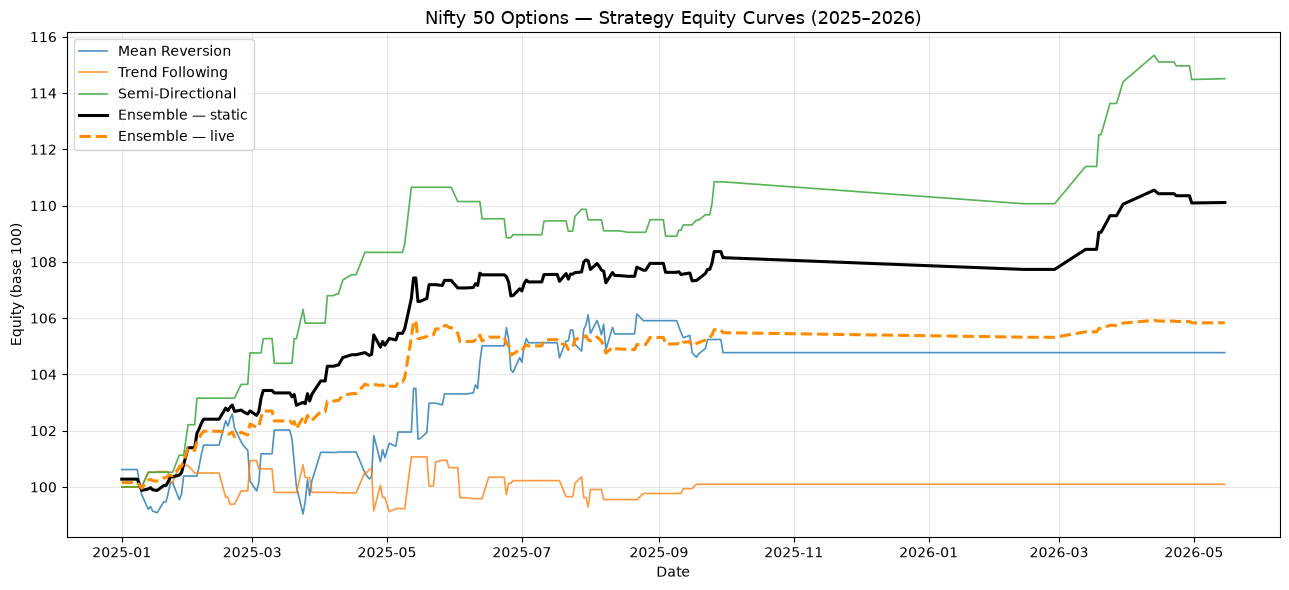

In [18]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(dates, pf['eq_mean'],   label='Mean Reversion',        lw=1.2, alpha=0.8)
ax.plot(dates, pf['eq_trend'],  label='Trend Following',       lw=1.2, alpha=0.8)
ax.plot(dates, pf['eq_semi'],   label='Semi-Directional',      lw=1.2, alpha=0.8)
ax.plot(dates, pf['eq_static'], label='Ensemble — static',     lw=2.2, color='black')
ax.plot(dates, pf['eq_live'],   label='Ensemble — live',       lw=2.2, color='darkorange', ls='--')
ax.set_title('Nifty 50 Options — Strategy Equity Curves (2025–2026)', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Equity (base 100)')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('equity_curves.png', dpi=150)
plt.show()


## 14 · Save Outputs


In [19]:
pf.to_csv('strategy_returns_log.csv', index=False)
mdf.to_csv('strategy_metrics_summary.csv')
print('Saved: strategy_returns_log.csv  |  strategy_metrics_summary.csv  |  equity_curves.png')


Saved: strategy_returns_log.csv  |  strategy_metrics_summary.csv  |  equity_curves.png


## 15 · Regime Diagnostic — IV Term Structure & Hurst (optional, slow)

> Informational only — does not affect signals or ensemble weights.  
> Requires `statsmodels`. Skip this cell if speed matters.


In [20]:
def run_regime_diagnostic():
    try:
        from statsmodels.tsa.stattools import adfuller
    except ImportError:
        print('[Regime diagnostic] statsmodels not installed — skipping.'); return

    SPLIT = pd.Timestamp('2025-01-17')

    def bs_price(S, K, T, r, sigma, opt):
        if T<=0 or sigma<=0: return max(0.0,(S-K) if opt=='C' else (K-S))
        d1=(np.log(S/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T)); d2=d1-sigma*np.sqrt(T)
        return S*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2) if opt=='C' else K*np.exp(-r*T)*norm.cdf(-d2)-S*norm.cdf(-d1)

    def implied_vol(price, S, K, T, r, opt):
        if T<=0 or price<=0: return np.nan
        if price <= max(0.0,(S-K) if opt=='C' else (K-S))+1e-6: return np.nan
        try: return brentq(lambda sig: bs_price(S,K,T,r,sig,opt)-price, 1e-4, 5.0, maxiter=200)
        except: return np.nan

    eod_ts  = atm_df.groupby(atm_df['bar_minute'].dt.date)['bar_minute'].transform('max')
    atm_eod = atm_df[atm_df['bar_minute']==eod_ts][['bar_minute','spot']].copy()
    full_eod= raw[raw['bar_minute'].isin(atm_eod['bar_minute'])].copy()

    exp_r = full_eod[['bar_minute','expiry']].drop_duplicates().sort_values(['bar_minute','expiry'])
    exp_r['rank'] = exp_r.groupby('bar_minute').cumcount()
    fe = exp_r[exp_r['rank']==0][['bar_minute','expiry']].rename(columns={'expiry':'front_expiry'})
    ne = exp_r[exp_r['rank']==1][['bar_minute','expiry']].rename(columns={'expiry':'next_expiry'})
    term = fe.merge(ne, on='bar_minute').merge(atm_eod, on='bar_minute')
    if len(term)==0: print('[Regime] No term structure rows.'); return

    def atm_iv_series(expiry_col):
        em  = term[['bar_minute',expiry_col]].rename(columns={expiry_col:'expiry'})
        sub = em.merge(full_eod, on=['bar_minute','expiry']).merge(atm_eod, on='bar_minute')
        if len(sub)==0: return pd.DataFrame(columns=['bar_minute','atm_iv'])
        sub['dist'] = (sub['strike']-sub['spot']).abs()
        best = sub.loc[sub.groupby('bar_minute')['dist'].idxmin(), ['bar_minute','strike']].rename(columns={'strike':'atm_strike'})
        sub  = sub.merge(best, on='bar_minute')[lambda df: df['strike']==df['atm_strike']]
        piv  = sub.pivot_table(index=['bar_minute','spot','expiry','strike'], columns='opt_type', values='close', aggfunc='first').reset_index().dropna(subset=['C','P'])
        piv['T'] = (piv['expiry']-piv['bar_minute']).dt.total_seconds()/(365.25*24*3600)
        piv['atm_iv'] = piv.apply(lambda r: np.nanmean([implied_vol(r['C'],r['spot'],r['strike'],r['T'],RISK_FREE_RATE,'C'),
                                                         implied_vol(r['P'],r['spot'],r['strike'],r['T'],RISK_FREE_RATE,'P')]), axis=1)
        return piv[['bar_minute','atm_iv']]

    print('Computing IV term structure (EOD only) …')
    iv = atm_iv_series('front_expiry').rename(columns={'atm_iv':'front_iv'}).merge(
         atm_iv_series('next_expiry').rename(columns={'atm_iv':'next_iv'}), on='bar_minute')
    iv['date']  = pd.to_datetime(iv['bar_minute'].dt.date)
    iv['slope'] = iv['next_iv']-iv['front_iv']

    pre, post = iv[iv['date']<=SPLIT], iv[iv['date']>SPLIT]
    iv_summary = pd.DataFrame([
        {'Period':'Pre-split',  'Days':len(pre),  'Front IV':f"{pre['front_iv'].mean():.4f}",  'Slope':f"{pre['slope'].mean():.4f}",  'Backwardation%':f"{(pre['slope']<0).mean():.1%}"},
        {'Period':'Post-split', 'Days':len(post), 'Front IV':f"{post['front_iv'].mean():.4f}", 'Slope':f"{post['slope'].mean():.4f}", 'Backwardation%':f"{(post['slope']<0).mean():.1%}"},
    ]).set_index('Period')
    display(iv_summary)
    iv.to_csv('daily_atm_iv_term_structure.csv', index=False)

    def hurst(ts):
        ts = np.asarray(ts, dtype=float); lags = range(2,40)
        tau = [max(np.std(np.subtract(ts[l:],ts[:-l])),1e-8) for l in lags]
        return np.polyfit(np.log(list(lags)),np.log(tau),1)[0]*2.0

    daily_sub = daily[daily['spot_close'].notna()].copy()
    daily_sub['dt'] = pd.to_datetime(daily_sub['date'])
    pre_s  = daily_sub[daily_sub['dt']<=SPLIT]['spot_close'].values
    post_s = daily_sub[daily_sub['dt']> SPLIT]['spot_close'].values
    adp, adpo = adfuller(pre_s), adfuller(post_s)

    regime_summary = pd.DataFrame([
        {'Period':'Pre-split',  'Hurst':f'{hurst(pre_s):.3f}',  'ADF p-value':f'{adp[1]:.4f}'},
        {'Period':'Post-split', 'Hurst':f'{hurst(post_s):.3f}', 'ADF p-value':f'{adpo[1]:.4f}'},
    ]).set_index('Period')
    print('H < 0.5 => mean-reverting  |  H = 0.5 => random walk  |  H > 0.5 => trending')
    display(regime_summary)

run_regime_diagnostic()


[Regime diagnostic] statsmodels not installed — skipping.
